# Hotel Booking Cancellation – EDA and Data Cleaning

Cancellations make it hard for a hotel to plan rooms, staff and revenue. This notebook explores the Hotel Booking Demand dataset (bookings for a City Hotel and a Resort Hotel in Portugal, 2015–2017) and prepares a clean table for modelling.

The target is `is_canceled` (1 = cancelled, 0 = not cancelled). The end user is a hotel revenue manager who wants to know, **at the moment a booking is made**, how likely it is to be cancelled.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
palette = ['#2B5C8F', '#E05A47']

## 1. Load the data

In [2]:
df = pd.read_csv('../data/raw/hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
print(df.shape)
df.info()

(119390, 32)
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal          

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [5]:
df.nunique()

hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
assigned_room_type                  12
booking_changes                     21
deposit_type                         3
agent                              333
company                            352
days_in_waiting_list     

119,390 bookings and 32 columns. `describe()` already shows values to check: `adr` (average daily rate) runs from -6.38 to 5,400, and `adults` can be 0.

## 2. Missing values

Each column with gaps gets its own rule instead of one blanket fill.

In [6]:
missing = df.isnull().sum()
pd.DataFrame({'missing': missing, 'percent': (missing / len(df) * 100).round(2)})[missing > 0]

,missing,percent
children,4,0.00
country,488,0.41
agent,16340,13.69
company,112593,94.31


In [7]:
# is a missing agent just a booking made without one? check the distribution channel
pd.crosstab(df['agent'].isnull(), df['distribution_channel'], normalize='index').round(3)

distribution_channel,Corporate,Direct,GDS,TA/TO,Undefined
agent,,,,,
False,0.011,0.068,0.002,0.919,0.0
True,0.339,0.467,0.000,0.194,0.0


Bookings with no agent are mostly Direct (46.7%) or Corporate (33.9%), while bookings with an agent are 91.9% TA/TO. A missing agent means the guest booked without one, not that the value was lost.

In [8]:
# company is 94.3% empty - too sparse to learn anything from
df = df.drop(columns=['company'])

# NaN agent = booked without a travel agent, so 0 means "no agent"
df['agent'] = df['agent'].fillna(0).astype(int)

In [9]:
# country: compare the most common country with the rows that are missing
print(df['country'].value_counts(normalize=True).head(3).round(3))
print('PRT cancel rate:            ', round(df.loc[df['country'] == 'PRT', 'is_canceled'].mean(), 3))
print('missing-country cancel rate:', round(df.loc[df['country'].isnull(), 'is_canceled'].mean(), 3))

country
PRT    0.409
GBR    0.102
FRA    0.088
Name: proportion, dtype: float64
PRT cancel rate:             0.566
missing-country cancel rate: 0.137


PRT is 40.9% of bookings and cancels 56.6% of the time, but the 488 bookings with no country cancel only 13.7% of the time. Filling them with the mode (PRT) would give them the highest-cancelling label, so they get their own `Unknown` category.

In [10]:
# country: own category instead of the mode (see above)
df['country'] = df['country'].fillna('Unknown')

# children: only 4 missing rows, and 0 is by far the most common value
df['children'] = df['children'].fillna(0).astype(int)
df.isnull().sum().sum()

np.int64(0)

## 3. Impossible and incorrect rows

In [11]:
# a booking with no adults, children or babies is not a real stay
no_guests = (df['adults'] + df['children'] + df['babies']) == 0
print('bookings with zero guests:', no_guests.sum())
df = df[~no_guests]

bookings with zero guests: 180


In [12]:
print('lowest adr :', df['adr'].sort_values().head(3).values)
print('highest adr:', df['adr'].sort_values().tail(5).values)

lowest adr : [-6.38  0.    0.  ]
highest adr: [ 450.   451.5  508.   510.  5400. ]


One booking has a negative rate (-6.38) and one has 5,400 while the next highest is 510. Both are entry errors, so only those two rows go. Cutting a percentile (for example the top 1%) would also delete real peak-season bookings.

In [13]:
# remove only the two demonstrable errors, not a percentile
df = df[(df['adr'] >= 0) & (df['adr'] < 5000)]
df.shape

(119208, 31)

In [14]:
print(df['meal'].value_counts())

# the dataset documentation defines both 'Undefined' and 'SC' as "no meal package"
df['meal'] = df['meal'].replace('Undefined', 'SC')

meal
BB           92234
HB           14458
SC           10549
Undefined     1169
FB             798
Name: count, dtype: int64


## 4. Data leakage – columns the model must not see

We predict at booking time, so any column that is only filled in later would hand the model the answer.

In [15]:
pd.crosstab(df['reservation_status'], df['is_canceled'])

is_canceled,0,1
reservation_status,,
Canceled,0,42992
Check-Out,75010,0
No-Show,0,1206


`reservation_status` is the target written a second way: every `Canceled` and `No-Show` is a cancellation and every `Check-Out` is not. `reservation_status_date` is the date of that outcome.

In [16]:
# leakage: both columns record the outcome itself
df = df.drop(columns=['reservation_status', 'reservation_status_date'])

### 4.1 A column that is too good to be true

`required_car_parking_spaces` is worth stopping on, because at first glance it looks like the single
most predictive column in the dataset.

In [17]:
print(pd.crosstab(df['required_car_parking_spaces'], df['is_canceled']))

parked = df['required_car_parking_spaces'] > 0
print('\nbookings requesting parking:', parked.sum())
print('of those, cancelled       :', int(df.loc[parked, 'is_canceled'].sum()))
print('expected if unrelated     :', round(parked.sum() * df['is_canceled'].mean()))

is_canceled                      0      1
required_car_parking_spaces              
0                            67601  44198
1                             7376      0
2                               28      0
3                                3      0
8                                2      0

bookings requesting parking: 7409
of those, cancelled       : 0
expected if unrelated     : 2747


**7,409 bookings requested a parking space and not one of them was cancelled** - at every value, 1
space through 8. With an overall cancellation rate of 37%, about 2,747 of them should have cancelled.

A perfect split is not a strong feature, it is a warning. Suppose reserving parking really does mean a
guest is committed: then their cancellation rate should be *lower* than 37% - maybe 15%, maybe 5%. It
should not be zero. Real behaviour does not produce 0 out of 7,409; somebody's car breaks down,
somebody falls ill. The only thing that produces an exact zero is a column filled in from the stay
itself. A space is allocated when the guest arrives, and a cancelled booking has no arrival, so the
field stays 0.

`required_car_parking_spaces > 0` does not mean "this guest wants parking". It means **"this guest
turned up"** - the target, written in another column.

### 4.2 What a genuine booking-time request looks like

`total_of_special_requests` is the column parking is often confused with: something the guest asks for
while booking. Comparing the two is the clearest way to see the difference.

In [18]:
requests = df.groupby('total_of_special_requests')['is_canceled'].agg(['count', 'mean'])
requests['mean'] = (requests['mean'] * 100).round(1)
print(requests)

# does it still hold once lead time is accounted for, or is it just repeating it?
band = pd.cut(df['lead_time'], [-1, 30, 90, 365, 10**4],
              labels=['0-30', '31-90', '91-365', '366+'])
pd.crosstab(band, df['total_of_special_requests'] > 0, df['is_canceled'], aggfunc='mean').round(3)

                           count  mean
total_of_special_requests             
0                          70199  47.8
1                          33183  22.0
2                          12952  22.1
3                           2494  17.8
4                            340  10.6
5                             40   5.0


total_of_special_requests,False,True
lead_time,,
0-30,0.226,0.136
31-90,0.485,0.244
91-365,0.623,0.283
366+,0.846,0.036


The cancellation rate falls from **47.8%** with no requests to **5.0%** with five - and **never
reaches zero**. Even guests with five special requests still cancel one time in twenty. The fall is
not perfectly smooth (one request 22.0%, two requests 22.1% - effectively the same), but the
direction is unmistakable and the floor is real.

It also holds inside every lead-time band, so it is carrying its own information rather than
repeating `lead_time`: 22.6% against 13.6% for bookings within a month, and 84.6% against 3.6% for
bookings made more than a year ahead.

*(These counts are taken before duplicate rows are removed in section 5, so they cover all 119,210
remaining bookings. Section 6.6 revisits special requests on the deduplicated table.)*

| | `required_car_parking_spaces` | `total_of_special_requests` |
|---|---|---|
| shape | cliff to exactly 0 | gradient, 47.8% down to 5.0% |
| believable as behaviour? | no - 0 of 7,409 is impossible | yes |
| known when the booking is made? | no | yes |
| **decision** | **dropped** | **kept** |

Section 8 measures what each is worth: removing `total_of_special_requests` costs 0.0530 PR-AUC, the
largest single-feature effect in this notebook.

**The rule this gives us:** if a column separates the target perfectly, suspect how the data was
collected, not your luck. Perfect separation almost always means the column was written after the
outcome was known.

In [19]:
pd.crosstab(df['required_car_parking_spaces'] > 0, df['is_canceled'])

is_canceled,0,1
required_car_parking_spaces,,
False,67601,44198
True,7409,0


In [20]:
room_changed = df['reserved_room_type'] != df['assigned_room_type']
print(pd.crosstab(room_changed, df['is_canceled'], normalize='index').round(3))
print(df.groupby(df['booking_changes'] > 0)['is_canceled'].mean().round(3))
print(df.groupby(df['days_in_waiting_list'] > 0)['is_canceled'].mean().round(3))

is_canceled      0      1
row_0                    
False        0.584  0.416
True         0.946  0.054
booking_changes
False    0.409
True     0.157
Name: is_canceled, dtype: float64
days_in_waiting_list
False    0.362
True     0.639
Name: is_canceled, dtype: float64


None of the 7,409 bookings that asked for a parking space was cancelled, a perfect split that only makes sense if parking is recorded when the guest arrives. Guests given a different room from the one reserved cancel only 5.4% of the time, because rooms are assigned at check-in, and `booking_changes` (15.7% vs 40.9%) and `days_in_waiting_list` (63.9% vs 36.2%) keep changing after the booking date. None of these four columns is known when the booking is made, so all four are dropped.

In [21]:
# post-booking columns: filled in or updated after the reservation is made
df = df.drop(columns=['required_car_parking_spaces', 'assigned_room_type',
                      'booking_changes', 'days_in_waiting_list'])
df.shape

(119208, 25)

**What dropping them costs.** Putting all four back is worth **+0.0407 PR-AUC** - 0.8067 against the
0.7660 baseline (`reports/results/ablation.csv`, arm 6). That is a real number and it is the largest
honest-looking gain available anywhere in this notebook.

We pay it. Every one of those columns is filled in after the booking is made, so a model trained with
them cannot be run at the moment the prediction is actually needed: a booking arriving today has no
parking record, no room assignment and no change history yet. A model that scores well only because it
was told the answer is not a model, and the score it reports is not a score.

## 5. Duplicate rows

In [22]:
print('duplicate rows:', df.duplicated().sum())
print('cancel rate among duplicated rows:', round(df[df.duplicated(keep=False)]['is_canceled'].mean(), 3))

duplicate rows: 34239


cancel rate among duplicated rows: 0.559


34,239 rows are exact copies of another row. The dataset has no booking ID, so a copy cannot be told apart from a genuine repeat, and if copies stay, the same row can end up in both the training and the test set and inflate the test score. They are removed.

In [23]:
print('cancel rate before:', round(df['is_canceled'].mean(), 4))
df = df.drop_duplicates().reset_index(drop=True)
print('cancel rate after: ', round(df['is_canceled'].mean(), 4))
df.shape

cancel rate before: 0.3708


cancel rate after:  0.2775


(84969, 25)

The cancellation rate falls from 37.1% to 27.7%, because 55.9% of the duplicated rows were cancellations. 84,969 bookings remain.

**What the duplicates would have been worth.** Keeping them is not neutral for the score, it flatters
it: the same 25 features on the undeduplicated 119,208 rows reach **PR-AUC 0.9225 and ROC-AUC 0.945**,
against **0.7660 and 0.890** here (`reports/results/ablation.csv`, arm 7). That is a gain of 0.155 -
far larger than anything feature engineering achieves in this project.

It is not a real gain. Splitting at random puts copies of the same booking on both sides of the
train/test line, so the model is scored partly on rows it memorised. The gain is the model marking its
own homework, and it would disappear the moment the model met a genuinely new booking.

## 6. Exploratory data analysis

### 6.1 How many bookings are cancelled?

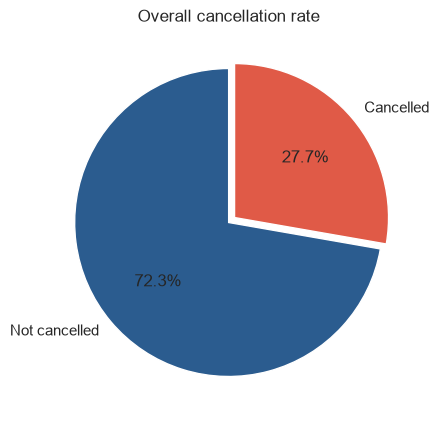

In [24]:
plt.figure(figsize=(5, 5))
plt.pie(df['is_canceled'].value_counts(), labels=['Not cancelled', 'Cancelled'],
        autopct='%1.1f%%', colors=palette, startangle=90, explode=(0, 0.05))
plt.title('Overall cancellation rate')
plt.show()

27.7% of bookings are cancelled. A model that always answers "not cancelled" would already be 72.3% accurate, so accuracy alone will not be a useful score for the models.

### 6.2 Hotel type

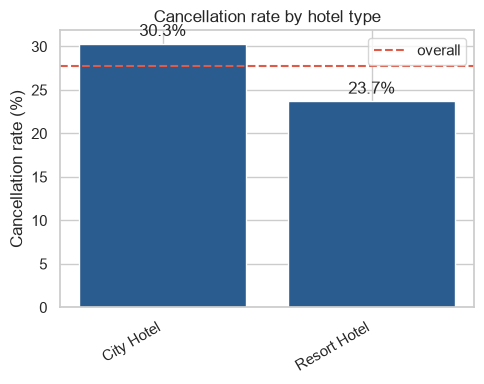

In [25]:
# cancel rate (%) for each group of a column, with the rate printed on each bar
def plot_cancel_rate(column, title, order=None, figsize=(7, 4)):
    rate = df.groupby(column, observed=True)['is_canceled'].mean().mul(100)
    if order is not None:
        rate = rate.reindex(order)
    plt.figure(figsize=figsize)
    bars = plt.bar(rate.index.astype(str), rate.values, color=palette[0])
    plt.bar_label(bars, fmt='%.1f%%', padding=3)
    plt.axhline(df['is_canceled'].mean() * 100, color=palette[1], linestyle='--', label='overall')
    plt.ylabel('Cancellation rate (%)')
    plt.title(title)
    plt.legend()
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

plot_cancel_rate('hotel', 'Cancellation rate by hotel type', figsize=(5, 4))

The City Hotel cancels more often than the Resort Hotel (30.3% vs 23.7%), so `hotel` stays as a feature.

### 6.3 Lead time

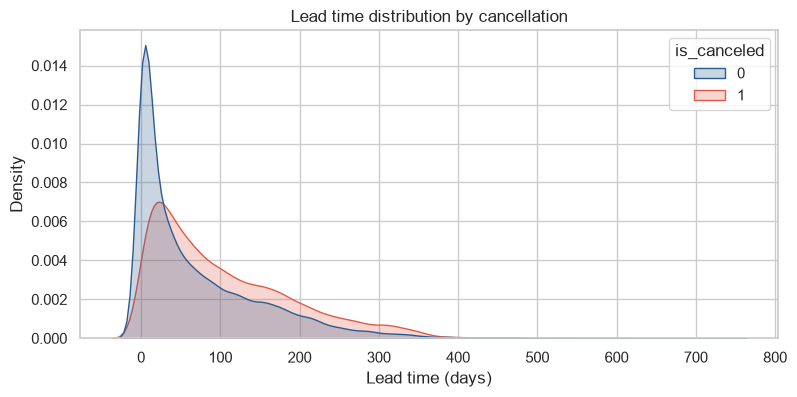

is_canceled
0    37.0
1    79.0
Name: lead_time, dtype: float64

In [26]:
plt.figure(figsize=(9, 4))
sns.kdeplot(data=df, x='lead_time', hue='is_canceled', fill=True, common_norm=False, palette=palette)
plt.title('Lead time distribution by cancellation')
plt.xlabel('Lead time (days)')
plt.show()

df.groupby('is_canceled')['lead_time'].median()

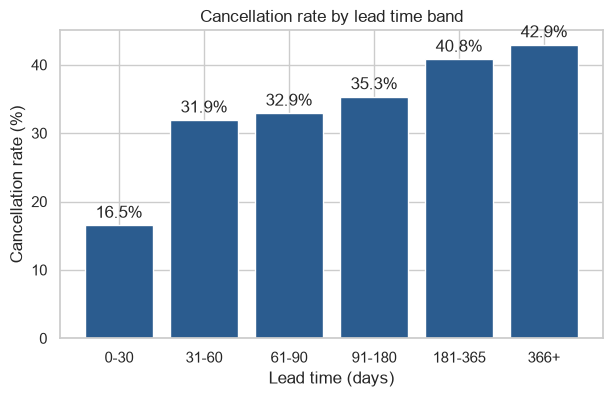

,count,mean
lead_time,,
0-30,33950,16.5
31-60,13013,31.9
61-90,9151,32.9
91-180,17752,35.3
181-365,10606,40.8
366+,497,42.9


In [27]:
lead_time_band = pd.cut(df['lead_time'], bins=[-1, 30, 60, 90, 180, 365, np.inf],
                        labels=['0-30', '31-60', '61-90', '91-180', '181-365', '366+'])
rate = df.groupby(lead_time_band, observed=True)['is_canceled'].agg(['count', 'mean'])
rate['mean'] = (rate['mean'] * 100).round(1)

plt.figure(figsize=(7, 4))
bars = plt.bar(rate.index.astype(str), rate['mean'], color=palette[0])
plt.bar_label(bars, fmt='%.1f%%', padding=3)
plt.xlabel('Lead time (days)')
plt.ylabel('Cancellation rate (%)')
plt.title('Cancellation rate by lead time band')
plt.show()

rate

Cancelled bookings were made much further ahead (median 79 days vs 37). The rate climbs from 16.5% for bookings made within 30 days to 40.8% at 181–365 days and 42.9% beyond a year, which makes lead time the clearest numeric signal.

### 6.4 Deposit type and customer type

deposit_type
No Deposit    83893
Non Refund      990
Refundable       86
Name: count, dtype: int64


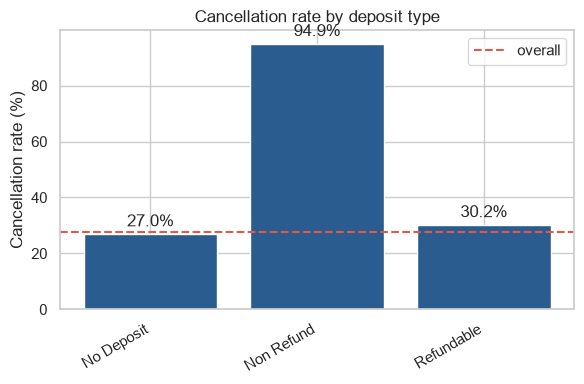

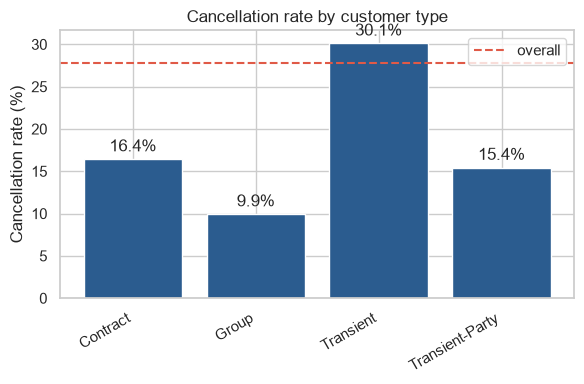

In [28]:
print(df['deposit_type'].value_counts())
plot_cancel_rate('deposit_type', 'Cancellation rate by deposit type', figsize=(6, 4))
plot_cancel_rate('customer_type', 'Cancellation rate by customer type', figsize=(6, 4))

Non Refund deposits cancel 94.9% of the time, but only 990 bookings use them, so this is a strong but narrow signal; almost every booking (83,893) has No Deposit. Among customer types, Transient bookings cancel most (30.1%) and Group bookings least (9.9%).

### 6.5 Market segment

market_segment
Online TA        51081
Offline TA/TO    13237
Direct           11617
Groups            4100
Corporate         4032
Complementary      677
Aviation           223
Undefined            2
Name: count, dtype: int64


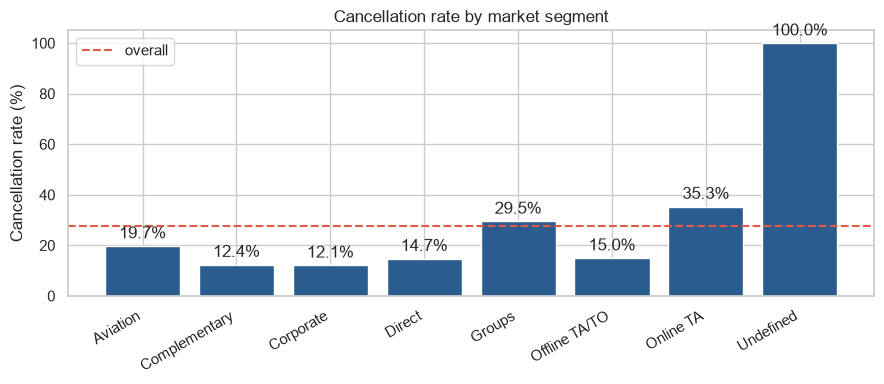

In [29]:
print(df['market_segment'].value_counts())
plot_cancel_rate('market_segment', 'Cancellation rate by market segment', figsize=(9, 4))

Online travel agents bring 51,081 bookings and have the highest rate of the large segments (35.3%), more than twice Offline TA/TO (15.0%) and Direct (14.7%). Corporate bookings are the most reliable at 12.1%.

### 6.6 Guest history and special requests

                        count   mean
previous_cancellations              
False                   83322  0.270
True                     1647  0.673
                   count   mean
is_repeated_guest              
0                  81626  0.286
1                   3343  0.077


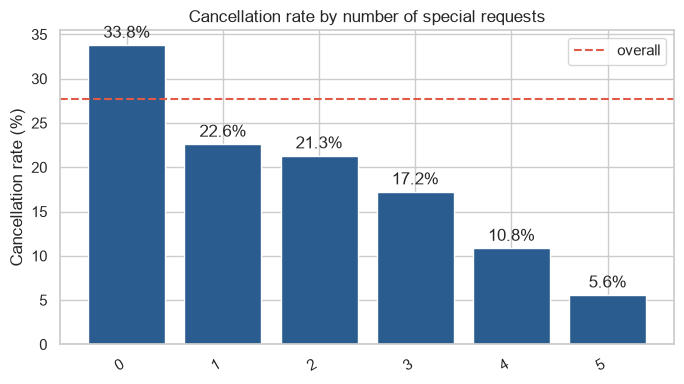

In [30]:
print(df.groupby(df['previous_cancellations'] > 0)['is_canceled'].agg(['count', 'mean']).round(3))
print(df.groupby('is_repeated_guest')['is_canceled'].agg(['count', 'mean']).round(3))
plot_cancel_rate('total_of_special_requests', 'Cancellation rate by number of special requests')

Guests with at least one previous cancellation cancel again 67.3% of the time (1,647 bookings), while repeat guests cancel only 7.7%. Special requests point the other way: 33.8% of bookings with no request are cancelled, falling to 10.8% with four requests, which suggests guests who ask for something intend to arrive.

### 6.7 Seasonality: cancellations and price by month

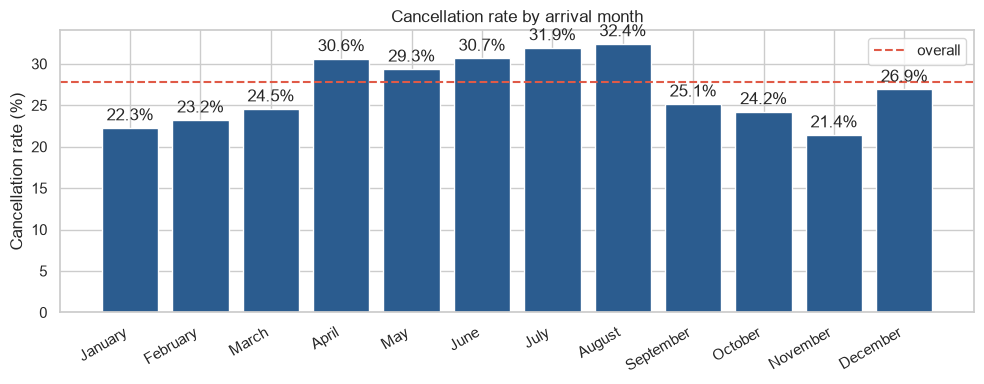

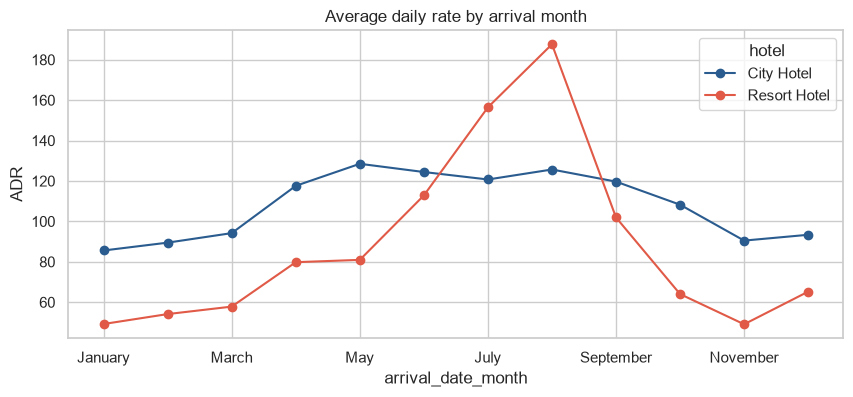

hotel               City Hotel  Resort Hotel
arrival_date_month                          
January                   86.0          49.0
February                  89.0          54.0
March                     94.0          58.0
April                    118.0          80.0
May                      128.0          81.0
June                     124.0         113.0
July                     121.0         156.0
August                   126.0         188.0
September                120.0         102.0
October                  108.0          64.0
November                  90.0          49.0
December                  93.0          65.0
is_canceled
0    102.8
1    118.0
Name: adr, dtype: float64


In [31]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
          'August', 'September', 'October', 'November', 'December']
plot_cancel_rate('arrival_date_month', 'Cancellation rate by arrival month', order=months, figsize=(10, 4))

monthly_adr = df.groupby(['arrival_date_month', 'hotel'])['adr'].mean().unstack().reindex(months)
monthly_adr.plot(marker='o', figsize=(10, 4), color=palette, title='Average daily rate by arrival month')
plt.ylabel('ADR')
plt.show()

print(monthly_adr.round(0))
print(df.groupby('is_canceled')['adr'].mean().round(1))

Cancellations peak in summer (August 32.4%, July 31.9%) and are lowest in November (21.4%) and January (22.3%). Resort Hotel prices follow the season, from 49 in January to 188 in August, while City Hotel prices stay between 86 and 128. Cancelled bookings were slightly more expensive on average (118.0 vs 102.8).

### 6.8 Where guests come from

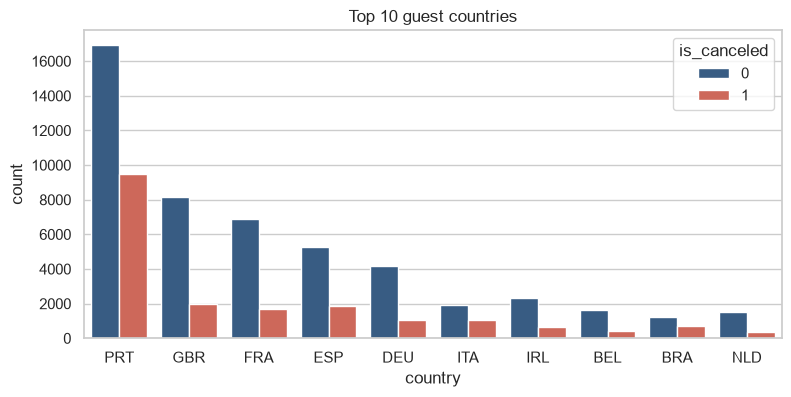

,count,mean
country,,
PRT,26439,0.359
GBR,10144,0.193
FRA,8624,0.199
ESP,7085,0.260
DEU,5221,0.199
ITA,2975,0.356
IRL,2957,0.221
BEL,2055,0.200
BRA,1969,0.367


In [32]:
top10 = df['country'].value_counts().head(10).index
plt.figure(figsize=(9, 4))
sns.countplot(data=df[df['country'].isin(top10)], x='country', hue='is_canceled',
              order=top10, palette=palette)
plt.title('Top 10 guest countries')
plt.show()

df[df['country'].isin(top10)].groupby('country')['is_canceled'].agg(['count', 'mean']) \
    .sort_values('count', ascending=False).round(3)

Portugal is by far the largest market (26,439 bookings) and, together with Brazil (36.7%) and Italy (35.6%), cancels the most (35.9%). Most other European markets sit between 18% and 26%. Country is kept; rare countries are grouped later during encoding.

### 6.9 Correlation between numeric columns

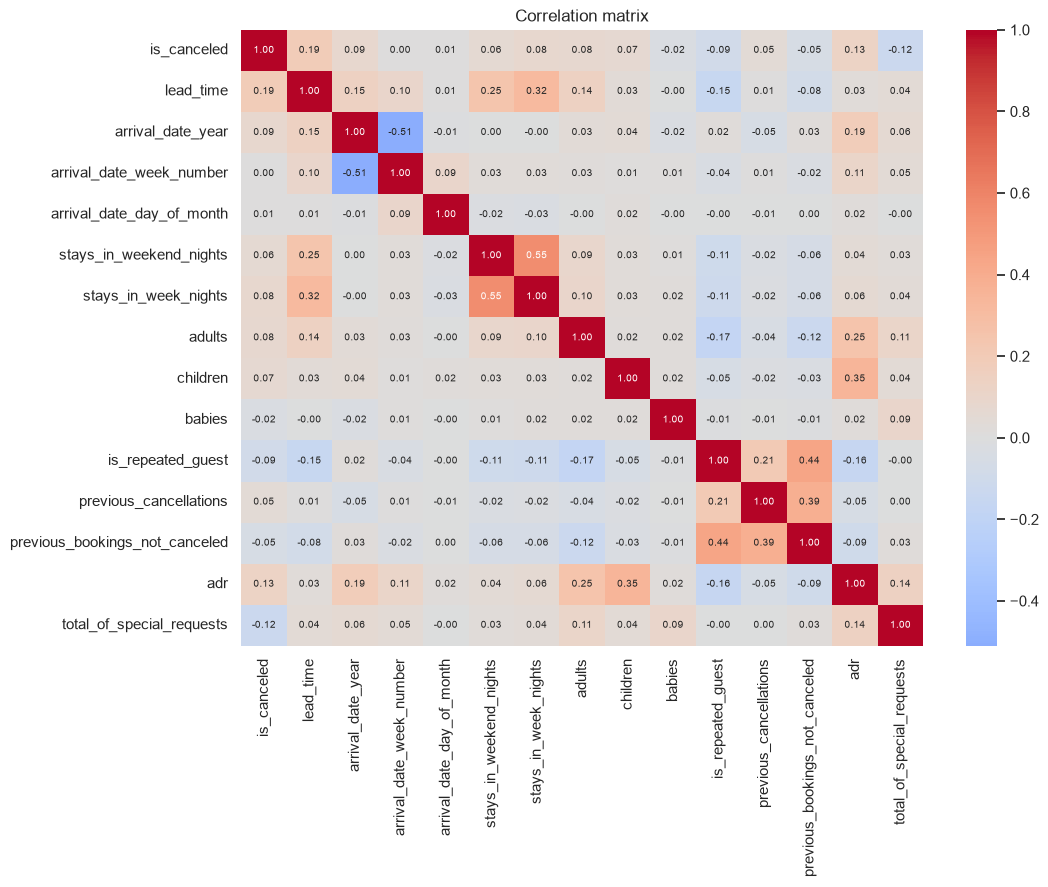

total_of_special_requests        -0.125
is_repeated_guest                -0.090
previous_bookings_not_canceled   -0.053
babies                           -0.022
arrival_date_week_number          0.004
arrival_date_day_of_month         0.005
previous_cancellations            0.050
stays_in_weekend_nights           0.058
children                          0.066
adults                            0.078
stays_in_week_nights              0.083
arrival_date_year                 0.085
adr                               0.131
lead_time                         0.192
Name: is_canceled, dtype: float64

In [33]:
# agent is an ID number, not a quantity, so it is left out of the correlation
numeric = df.select_dtypes('number').drop(columns=['agent'])

plt.figure(figsize=(11, 8))
sns.heatmap(numeric.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={'size': 7})
plt.title('Correlation matrix')
plt.show()

numeric.corr()['is_canceled'].drop('is_canceled').sort_values().round(3)

No numeric column is strongly correlated with cancellation on its own: the largest are `lead_time` (0.19), `adr` (0.13) and `total_of_special_requests` (-0.13). The categorical columns above (deposit type, market segment, country) show bigger differences, which is why they are kept for the models.

### 6.10 Scope: which bookings this model is valid for

`country` turned out to be one of the most useful columns in the data, which raises a fair objection:
a model that leans on nationality has learned something about *these* guests, not about hotel guests
in general. That objection is right, and the answer is to state the boundary rather than to blind the
model - so this section works out what the boundary actually is.

In [34]:
europe = {'PRT','GBR','FRA','ESP','DEU','ITA','IRL','BEL','NLD','CHE','AUT','SWE','POL','NOR',
          'DNK','RUS','ROU','FIN','LUX','CZE','GRC','HUN','HRV','SRB','BGR','SVK','SVN','EST',
          'LTU','LVA','ISL','UKR','TUR','MLT','CYP'}

def origin(c):
    if c == 'PRT':      return 'Portugal (domestic)'
    if c == 'Unknown':  return 'Unknown'
    return 'Rest of Europe' if c in europe else 'Outside Europe'

scope = df.groupby(df['country'].apply(origin))['is_canceled'].agg(['count', 'mean'])
scope['share_%'] = (scope['count'] / len(df) * 100).round(1)
scope['cancel_%'] = (scope['mean'] * 100).round(1)
print(scope[['count', 'share_%', 'cancel_%']].sort_values('count', ascending=False), '\n')

print('arrivals per year:'); print(df.groupby('arrival_date_year').size().to_string())
print()
print(df.groupby('hotel')['is_canceled'].agg(['count', 'mean']).round(3))

                     count  share_%  cancel_%
country                                      
Rest of Europe       48791     57.4      22.5
Portugal (domestic)  26439     31.1      35.9
Outside Europe        9297     10.9      32.8
Unknown                442      0.5       6.3 

arrivals per year:
arrival_date_year
2015    12597
2016    41269
2017    31103

              count   mean
hotel                     
City Hotel    51934  0.303
Resort Hotel  33035  0.237


**Guests.** 31.1% of bookings are domestic Portuguese and another 57.4% come from elsewhere in Europe
- **88.5% European in total**, with only 10.9% from outside. Domestic guests cancel at 35.9% against
22.5% for the rest of Europe, and that gap is most of why `country` is useful: a guest booking a hotel
in their own country can change their plans cheaply, while someone flying in from Britain or Germany
has already committed to flights.

**Period.** The data covers arrivals in 2015-2017 only, and 2015 and 2017 are partial years. It is
also entirely **pre-2020**, which matters more than the date range suggests: cancellation behaviour,
refund policies and booking lead times all changed sharply afterwards.

**Properties.** Two hotels, not a chain and not an industry - one City Hotel (51,934 bookings, 30.3%
cancelled) and one Resort Hotel (33,035, 23.7%). Prices are in euros at Portuguese market rates.

**What this means for the model.** It predicts cancellations for *European guests booking these two
Portuguese hotels between 2015 and 2017*. Inside that population it is a reasonable model; outside it,
it is not, and the same would be true of any model fitted to this data.

The alternative - dropping `country` to make the model "more general" - does not survive being applied
consistently. `agent` is one of the strongest columns in the data and is a set of travel-agent IDs
belonging to this business; `market_segment` and `distribution_channel` describe these properties'
sales channels; `adr` is in euros at local price levels. A rule that removes every column tied to this
business removes the model. Naming the population the model is for is the honest version of the same
concern, and it costs no accuracy.

### Key findings

- After cleaning, 27.7% of bookings are cancelled; the City Hotel cancels more than the Resort Hotel (30.3% vs 23.7%).
- Lead time is the clearest numeric driver: 16.5% within 30 days against 40.8% at 181–365 days.
- Non Refund deposits (94.9%) and a history of cancelling (67.3%) mark high risk, but both are small groups.
- Online TA is the riskiest large segment (35.3%); special requests and repeat guests point to lower risk.
- Six columns were removed as leakage or post-booking information, so the models only see what is known at booking time.

## 7. Feature engineering

In [35]:
# total_nights: one length-of-stay number instead of a weekday/weekend split
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# total_guests: party size in one column
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# is_family: bookings with children or babies may behave differently (checked below)
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)

print(df[['total_nights', 'total_guests', 'is_family']].describe().T)
df.groupby('is_family')['is_canceled'].agg(['count', 'mean']).round(3)

                count      mean       std  min  25%  50%  75%   max
total_nights  84969.0  3.645718  2.754549  0.0  2.0  3.0  5.0  69.0
total_guests  84969.0  2.037378  0.793632  1.0  2.0  2.0  2.0  55.0
is_family     84969.0  0.106592  0.308595  0.0  0.0  0.0  0.0   1.0


,count,mean
is_family,,
0,75912,0.270
1,9057,0.342


Families cancel more often than other bookings (34.2% vs 27.0%). The flag puts that into one column instead of leaving the model to combine `children` and `babies`.

### 7.1 Candidate features, tested and rejected

Several further features are plausible on this data and are commonly built for this problem. Each one
was measured before being adopted: `scripts/ablation.py` adds it to the 25-feature set, scores it with
the same XGBoost over the same 5 folds, and writes the result to `reports/results/ablation.csv`.

The bar is the fold-to-fold noise: baseline PR-AUC is **0.7660 +/- 0.0071**, so a feature has to add
more than about 0.007 to be doing anything a rerun would not undo.

In [36]:
# the four candidates, built here so they can be looked at - none is added to df
prev_total = df['previous_cancellations'] + df['previous_bookings_not_canceled']
candidates = pd.DataFrame({
    # a continuous ratio, banded so the cancellation rate is readable
    'prev_cancel_ratio': pd.cut(df['previous_cancellations'] / prev_total.replace(0, 1),
                                bins=[-0.01, 0, 0.5, 0.99, 1.0],
                                labels=['0', '0-0.5', '0.5-1', '1']),
    'long_lead_time': (df['lead_time'] > 90).astype(int),
    'arrival_quarter': pd.cut(df['arrival_date_week_number'], bins=[0, 13, 26, 39, 53],
                              labels=['1', '2', '3', '4']).astype(str),
})

for col in candidates:
    print(df.groupby(candidates[col], observed=True)['is_canceled'].agg(['count', 'mean']).round(3), chr(10))


                   count   mean
prev_cancel_ratio              
0                  83322  0.270
0-0.5                588  0.167
0.5-1                 37  0.378
1                   1022  0.976 

                count   mean
long_lead_time              
0               56114  0.228
1               28855  0.374 

                 count   mean
arrival_quarter              
1                17380  0.235
2                23349  0.301
3                26842  0.306
4                17398  0.243 



Each one separates the groups a little, but less cleanly than it first appears. The
previous-cancellation ratio only matters at the extreme: the 1,022 guests who cancelled every
previous booking cancel again 97.6% of the time, but the 588 guests with a ratio between 0 and 0.5
cancel **16.7%** of the time - *below* the 27.7% base rate for the whole table. It is not a rising
scale, it is one small high-risk group that `previous_cancellations` already identifies on its own.
Bookings made more than 90 days ahead cancel 37.4% against 22.8%, and the summer quarters cancel a few
points more than winter - both of which `lead_time` and `arrival_date_month` already say, in more
detail.

That is why none of them adds anything once those columns are in the model. Two further candidates
behaved the same way: `booked_by_company` (company bookings cancel 11.1% against 28.8%, which looks
promising until `market_segment`, `distribution_channel` and `agent` are already in the model and have
said the same thing) and `adr_per_person`, which divides the rate by party size.

| candidate | PR-AUC delta | verdict |
|---|---|---|
| `prev_cancel_ratio` + `total_previous_bookings` | **-0.0007** | rejected, slightly worse |
| `long_lead_time` | **-0.0001** | rejected, no effect |
| `arrival_quarter` | **+0.0018** | rejected, a quarter of the noise floor |
| `booked_by_company` | **-0.0001** | rejected, no effect |
| `adr_per_person` | **-0.0008** | rejected, slightly worse |
| `booked_by_company` + `adr_per_person` | **-0.0011** | rejected |
| the first three together | **+0.0026** | rejected, they do not add up either |

Seven candidates, none of them worth a column. They are not adding information to a model that already
has `lead_time`, `previous_cancellations` and `arrival_date_month` - they are restating it.

None is added. The clean table keeps the three features built above.

### 7.2 `room_changed`, and why it stays out

A tempting feature here is `room_changed = reserved_room_type != assigned_room_type`, on the theory
that a guest moved to a different room is an unhappy guest. Unlike the seven above it genuinely works:
**+0.0144 PR-AUC**, twice the noise floor and the largest single feature effect measured here.

It stays out anyway. `assigned_room_type` is the room the guest was actually put in, which is settled
at check-in - for a cancelled booking there is no check-in at all. A model that needs it cannot be run
on the booking it is supposed to score, which is the same reason section 4 drops that column. A
feature that improves the number and cannot be computed when the prediction is needed is not an
improvement, it is a leak with a good score.

Recorded here with its number so the next person does not have to rediscover it.

## 8. Stress tests: is the strongest feature really doing the work?

A feature that looks important in a chart is not necessarily a feature the model depends on. The check
is to take it away and re-measure. `scripts/ablation.py` does this by dropping one column from the 25
and re-scoring; baseline is **PR-AUC 0.7660 +/- 0.0071**.

| column removed | PR-AUC | change | reading |
|---|---|---|---|
| nothing (baseline) | 0.7660 | - | |
| `total_of_special_requests` | **0.7130** | **-0.0530** | the model genuinely leans on it |
| `deposit_type` | 0.7620 | -0.0040 | barely used, despite the 94.9% headline |

**The dramatic column and the useful column are not the same column.** `deposit_type` gives the most
striking number in the whole EDA - Non Refund bookings cancel 94.9% of the time - and removing it
costs almost nothing, because it only covers 990 of 84,969 bookings. `total_of_special_requests` makes
a far less exciting chart and is worth thirteen times more to the model.

Section 6.6 is where that chart lives. It is worth reading the two together.

## 9. Save the clean data

In [37]:
df.to_csv('../data/processed/hotel_bookings_clean.csv', index=False)
print(df.shape)
df.columns.tolist()

(84969, 28)


['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'deposit_type',
 'agent',
 'customer_type',
 'adr',
 'total_of_special_requests',
 'total_nights',
 'total_guests',
 'is_family']

The clean table has 84,969 bookings and 28 columns (27 candidate features plus the target), saved to
`data/processed/hotel_bookings_clean.csv`.

Seven candidate features were built, measured and rejected (7.1); `room_changed` was rejected despite
working, because it is not knowable at booking time (7.2); and the two stress tests in section 8 show
which of the remaining columns the model actually leans on.

`02_preprocessing.ipynb` takes this table, decides the encoding, and splits it into training and test
sets.